**SVM - Binary**

In [75]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

import warnings
warnings.filterwarnings("ignore")

In [76]:
data = pd.read_csv('C:/MAFAS/APU/CT046-3-M-AML/CT046 - LABS/Python LAB MATERIALS/Lab 8 - SVM/diabetes.csv')
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [77]:
data.shape

(768, 9)

In [78]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [79]:
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [80]:
data['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

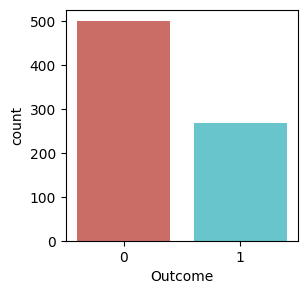

<Figure size 640x480 with 0 Axes>

In [81]:
# class distribution 
plt.figure(figsize = (3,3))
sns.countplot(x = 'Outcome', data = data, palette='hls')
plt.show()
plt.savefig('Outcome')

In [82]:
x = data.drop('Outcome', axis = 1)
y = data['Outcome']

In [83]:
# Data Splitting
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.20, random_state = 42)

**Class balancing**

Class balancing should be done only on the training data.

Counter({0: 401, 1: 401})


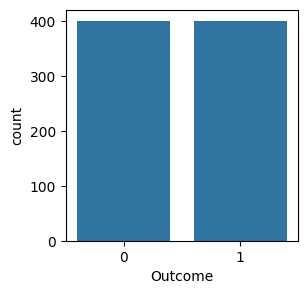

In [84]:
from collections import Counter
from imblearn.over_sampling import SMOTE
x_train_b, y_train_b = SMOTE().fit_resample(x_train, y_train)

plt.subplots(figsize = (3,3))
sns.countplot(x = y_train_b)
print(Counter(y_train_b))

In [85]:
# Feature Scaling
sc = StandardScaler()
x_train_sc = sc.fit_transform(x_train_b)
x_test_sc = sc.transform(x_test)

**SVC - Base Model with balanced dataset**

In [86]:
svc = SVC()
svc.fit(x_train_sc, y_train_b)

y_pred_1 = svc.predict(x_test_sc)
acc = accuracy_score(y_test, y_pred_1) * 100
print("SVM - Accuracy: {:.3f}.".format(acc))
print("F1 Score: {:.3f}.".format(f1_score(y_test, y_pred_1), average = 'weighted'))
print("\nClassification Report")
print(classification_report(y_test, y_pred_1))

SVM - Accuracy: 70.779.
F1 Score: 0.622.

Classification Report
              precision    recall  f1-score   support

           0       0.80      0.73      0.76        99
           1       0.58      0.67      0.62        55

    accuracy                           0.71       154
   macro avg       0.69      0.70      0.69       154
weighted avg       0.72      0.71      0.71       154



**Grid Search CV with balanced dataset**

In [87]:
from sklearn.model_selection import GridSearchCV
from numpy import arange
model_svc = SVC()

parameters = dict()
parameters['kernel'] = ['rbf', 'poly', 'linear', 'sigmoid']
parameters['C'] = arange(1, 10, 1)
parameters['gamma'] = ['scale', 'auto']

from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits = 3, shuffle = True, random_state = 42)

## Building Grid Search algorithm with cross-validation and acc score.
grid_search_svc = GridSearchCV(model_svc, parameters, scoring = 'accuracy', cv = skf)

## Lastly, finding the best parameters.
grid_search_svc.fit(x_train_sc, y_train_b)
best_parameters_SVC_2 = grid_search_svc.best_params_  
best_score_SVC_2 = grid_search_svc.best_score_ 
print()
print(best_parameters_SVC_2)
print(best_score_SVC_2)

best_model = grid_search_svc.best_estimator_
y_pred_2 = best_model.predict(x_test_sc)

# Get the accuracy score
svc_acc_2 = accuracy_score(y_test, y_pred_2)*100
svc_pre_2 = precision_score(y_test, y_pred_2, average = 'weighted')
svc_recall_2 = recall_score(y_test, y_pred_2, average = 'weighted')
svc_f1_2 = f1_score(y_test, y_pred_2, average = 'weighted')

print("\nSVM - Accuracy: {:.3f}.".format(svc_acc_2))
print("SVM - Precision: {:.3f}.".format(svc_pre_2))
print("SVM - Recall: {:.3f}.".format(svc_recall_2))
print("SVM - F1 Score: {:.3f}.".format(svc_f1_2))
print ('\n Clasification Report:\n', classification_report(y_test,y_pred_2))


{'C': np.int64(9), 'gamma': 'scale', 'kernel': 'rbf'}
0.7855059906460208

SVM - Accuracy: 70.779.
SVM - Precision: 0.724.
SVM - Recall: 0.708.
SVM - F1 Score: 0.712.

 Clasification Report:
               precision    recall  f1-score   support

           0       0.81      0.72      0.76        99
           1       0.58      0.69      0.63        55

    accuracy                           0.71       154
   macro avg       0.69      0.70      0.69       154
weighted avg       0.72      0.71      0.71       154

